# Desafio de Ciência de Dados da Klike — Solução

**Autora:** Maria Moura
**Data:** 03/04/2026

**Objetivo Principal:**
Analisar um conjunto de dados de 500 campanhas de anúncios em vídeo da plataforma Klike (Millai) para:
1. Realizar análise exploratória de dados e revelar insights para as equipes de marketing
2. Construir um modelo de regressão para prever a **`klike_score`** (pontuação de qualidade criativa de 0 a 100)
3. Construir um **Mecanismo de Recomendações** que receba uma linha de campanha e forneça sugestões de melhoria quantificáveis ​​e acionáveis
4. Discutir a visão de produto/engenharia para a criação do mecanismo

**Variável Alvo:** `klike_score` — uma pontuação composta de 0 a 100 calculada pelo sistema de IA da Klike

**Métricas de Avaliação:** RMSE, MAE, R² (regressão); Relevância comercial da importância das funcionalidades

**Principais restrições/requisitos:**
- As recomendações devem ser **acionáveis, quantificáveis ​​e contextualizadas** (plataforma/categoria/faixa etária)
- Pelo menos 3 visualizações adequadas para um público de marketing
- Pelo menos 2 modelos de regressão comparados
- O mecanismo de recomendações deve aceitar uma única linha de campanha e retornar sugestões ordenadas
- `random_state=42` usado em todo o processo para garantir a reprodutibilidade

# 1. Visão Geral do Projeto

## Contexto do Desafio

**Millai** é uma consultoria de Marketing + IA. Seu principal produto, **Klike**, analisa anúncios em vídeo, atribui pontuações (de 0 a 100, `klike_score`) e recomenda melhorias.

O conjunto de dados contém **500 registros simulados** de campanhas em vídeo no Meta, TikTok e LinkedIn, cada uma com:
- **Atributos criativos**: formato, duração, legenda, gancho, rosto, densidade de texto, proporção música/voz
- **Metadados de segmentação**: plataforma, categoria, faixa etária, indicador de remarketing, objetivo
- **KPIs de desempenho**: impressões, cliques, CTR, CPC, investimento, conversões, receita, ROAS, tempo de exibição, taxa de engajamento
- **Alvo**: `klike_score`

### Desafio em quatro partes:
| Parte | Tarefa |

| 1 | Análise Exploratória de Dados |

| 2 | Modelo de regressão para `klike_score` |

| 3 | Motor de recomendações (acionável, quantificado, sensível ao contexto) |
| 4 | Visão do produto (texto — consulte o arquivo README) |

# 2. Configuração e Importações

In [1]:
# Instala bibliotecas que não são padrôes Colab.
!pip install shap --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SHAP 
import shap

# Saida limpa 
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('Todas as bibliotecas foram carregadas com sucesso.')

/home/maria/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Todas as bibliotecas foram carregadas com sucesso.


/home/maria/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Carregamento dos Dados

In [3]:
# Data path 
DATA_PATH = 'klike_challenge_dataset.csv'

# Carrega o dataset
df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}')

Dataset shape: (500, 26)
Columns (26): ['campaign_id', 'date', 'platform', 'category', 'objective', 'target_audience_age', 'is_retargeting', 'video_duration_s', 'format', 'has_subtitle', 'has_cta', 'has_hook', 'has_face', 'text_density', 'music_voice_ratio', 'impressions', 'clicks', 'ctr', 'cpc', 'spend', 'conversions', 'revenue', 'roas', 'avg_watch_time_s', 'engagement_rate', 'klike_score']


In [4]:
# Exibe os tipos de dado das colunas
print('Column dtypes:')
print(df_raw.dtypes)

Column dtypes:
campaign_id             object
date                    object
platform                object
category                object
objective               object
target_audience_age     object
is_retargeting            bool
video_duration_s       float64
format                  object
has_subtitle            object
has_cta                   bool
has_hook                  bool
has_face                  bool
text_density            object
music_voice_ratio      float64
impressions              int64
clicks                   int64
ctr                    float64
cpc                    float64
spend                  float64
conversions              int64
revenue                float64
roas                   float64
avg_watch_time_s       float64
engagement_rate        float64
klike_score            float64
dtype: object


In [5]:
# Exibe as primeiras linhas
df_raw.head()

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,...,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,...,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,...,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,...,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,...,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,...,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9


In [6]:
# Resumo estatístico rápido das colunas numéricas
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
video_duration_s,461.000000,19.392625,13.529351,5.000000,11.000000,16.000000,25.000000,115.000000
music_voice_ratio,462.000000,0.399848,0.202674,0.020000,0.230000,0.385000,0.550000,0.920000
impressions,500.000000,153738.524000,1171735.612393,1000.000000,9986.000000,23241.000000,55172.750000,14052761.000000
clicks,500.000000,3594.104000,7018.212512,4.000000,461.750000,1351.000000,3583.250000,72545.000000
ctr,500.000000,0.070968,0.045302,0.002200,0.033200,0.062750,0.104800,0.150000
cpc,472.000000,1.112903,1.955625,0.050000,0.530000,0.710000,1.020000,26.050000
spend,500.000000,4213.151620,11573.975576,2.960000,313.452500,1031.000000,2867.952500,121226.100000
conversions,500.000000,131.352000,314.565400,0.000000,10.000000,34.500000,111.000000,3666.000000
revenue,475.000000,6367.936863,19267.180696,0.000000,262.175000,1201.050000,4189.025000,241597.290000
roas,500.000000,2.499000,3.592365,0.000000,0.430000,1.490000,3.250000,39.920000


# 4. Análise Exploratória de Dados (EDA)

## 4.1 Valores Ausentes

Columns with missing values:
                   count  pct
has_subtitle          46  9.2
video_duration_s      39  7.8
music_voice_ratio     38  7.6
engagement_rate       32  6.4
cpc                   28  5.6
avg_watch_time_s      27  5.4
revenue               25  5.0


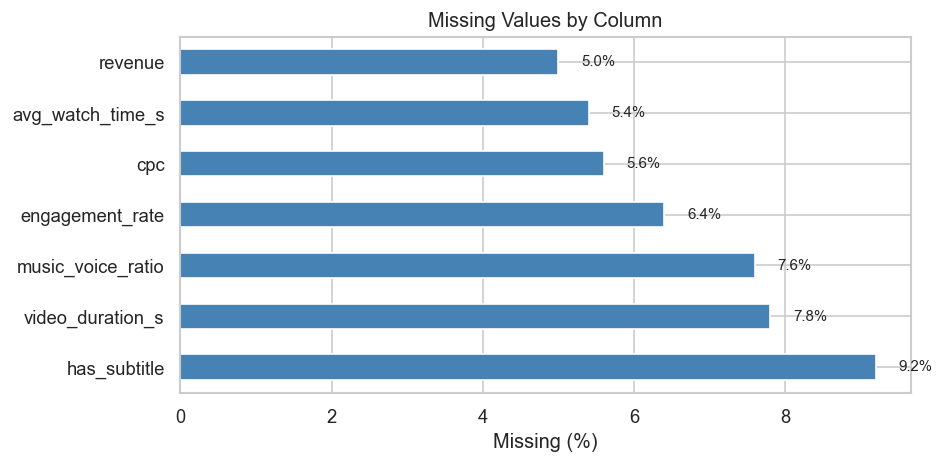

In [7]:
# Contagem e percentual de valores ausentes por coluna, dessa forma conseguimos verificar a contagem e percentual de valores nulos
missing = pd.DataFrame({
    'count': df_raw.isnull().sum(),
    'pct': (df_raw.isnull().mean() * 100).round(1)
}).query('count > 0').sort_values('pct', ascending=False)

print('Columns with missing values:')
print(missing)

# Visualiza os valores ausentes
fig, ax = plt.subplots(figsize=(8, 4))
missing['pct'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
for i, (idx, row) in enumerate(missing.iterrows()):
    ax.text(row['pct'] + 0.3, i, f"{row['pct']}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Análise de valores ausentes:**
- `has_subtitle` (~9%): provavelmente ausente quando o atributo não foi registrado — será imputado pela moda
- `video_duration_s` (~8%): ausente para alguns criativos; será imputado pela mediana por plataforma (mais curto no TikTok/Meta, mais longo no LinkedIn)
- `music_voice_ratio`, `engagement_rate`, `avg_watch_time_s`, `cpc`, `revenue` (~5–8%): colunas numéricas serão imputadas pela mediana

## 4.2 Distribuições Univariadas

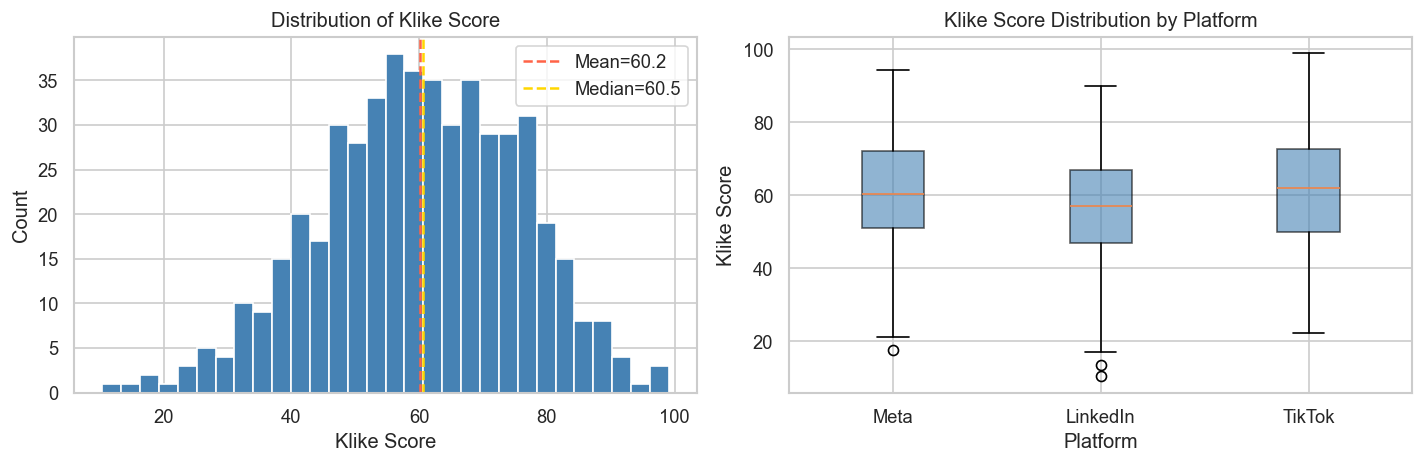

          count   mean    std   min    25%   50%    75%   max
platform                                                     
LinkedIn   83.0  56.31  15.90  10.4  46.85  57.2  66.85  90.0
Meta      241.0  60.40  15.04  17.6  51.00  60.5  72.10  94.4
TikTok    176.0  61.65  15.96  22.4  49.98  62.0  72.85  99.1


In [8]:
# Distribuição da variável-alvo klike_score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df_raw['klike_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_raw['klike_score'].mean(), color='tomato', linestyle='--', label=f"Mean={df_raw['klike_score'].mean():.1f}")
axes[0].axvline(df_raw['klike_score'].median(), color='gold', linestyle='--', label=f"Median={df_raw['klike_score'].median():.1f}")
axes[0].set_xlabel('Klike Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Klike Score')
axes[0].legend()

# Box plot por plataforma
platforms = df_raw['platform'].unique()
data_by_platform = [df_raw.loc[df_raw['platform'] == p, 'klike_score'].dropna().values for p in platforms]
bp = axes[1].boxplot(data_by_platform, labels=platforms, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Klike Score')
axes[1].set_title('Klike Score Distribution by Platform')

plt.tight_layout()
plt.show()

print(df_raw.groupby('platform')['klike_score'].describe().round(2))

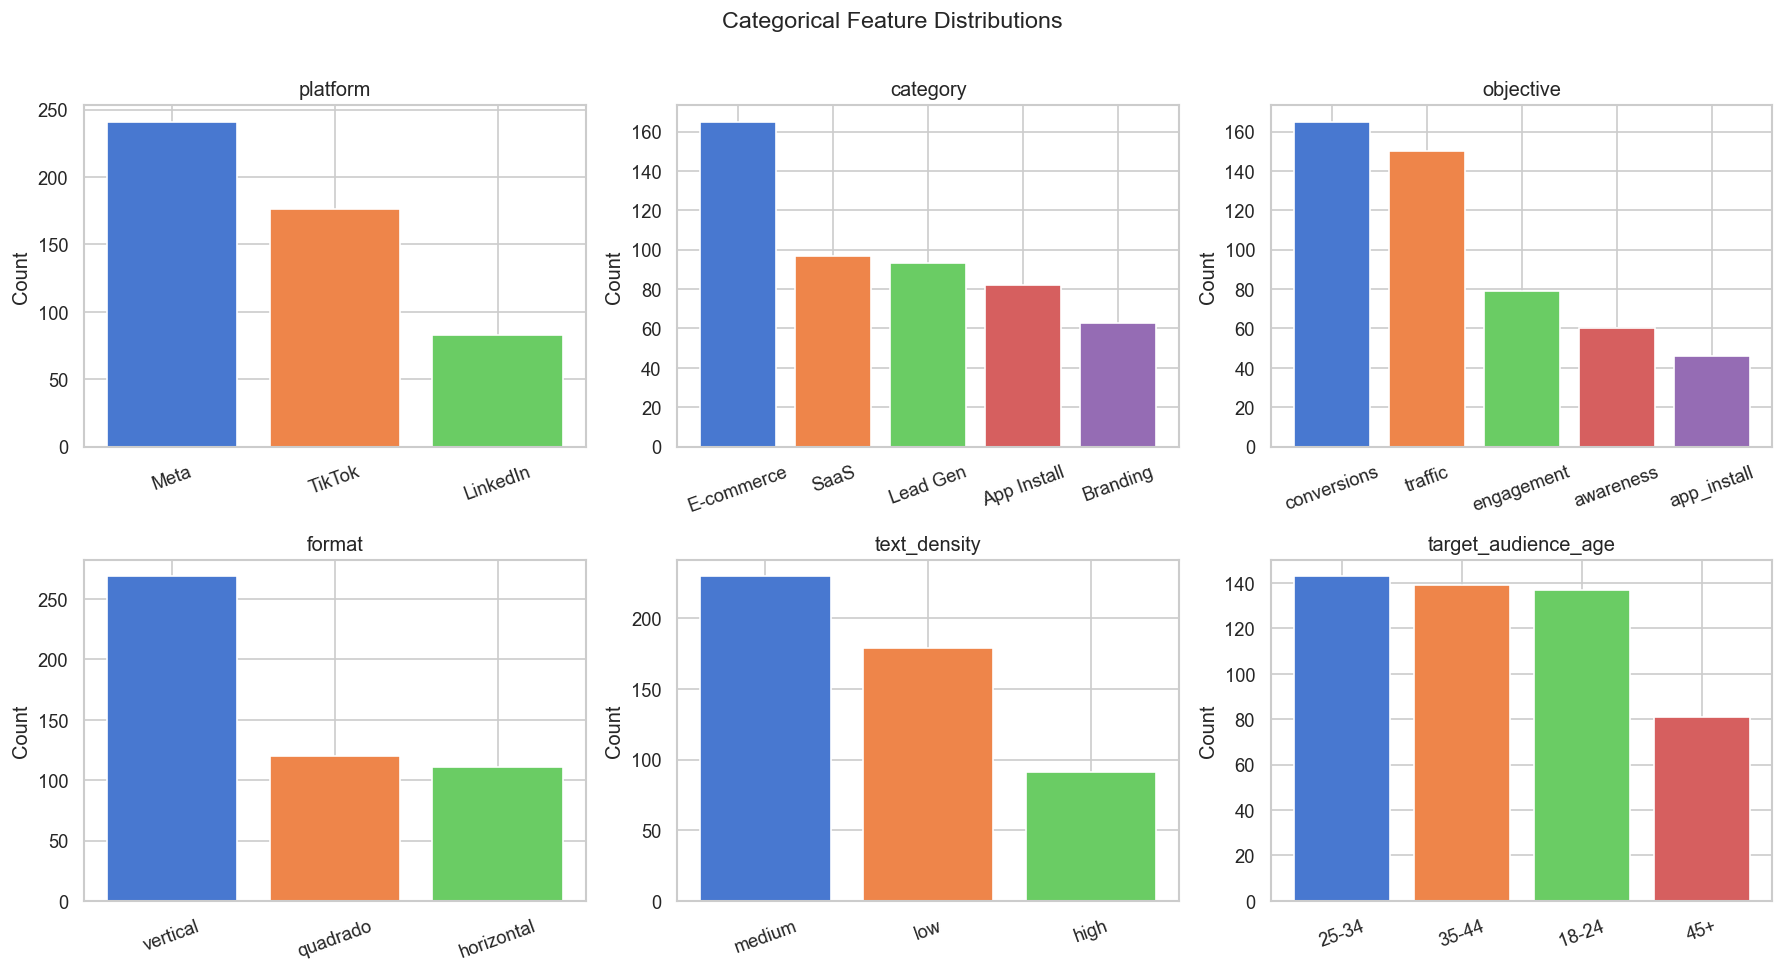

In [9]:
# Distribuição dos atributos criativos categóricos
cat_cols = ['platform', 'category', 'objective', 'format', 'text_density', 'target_audience_age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_raw[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

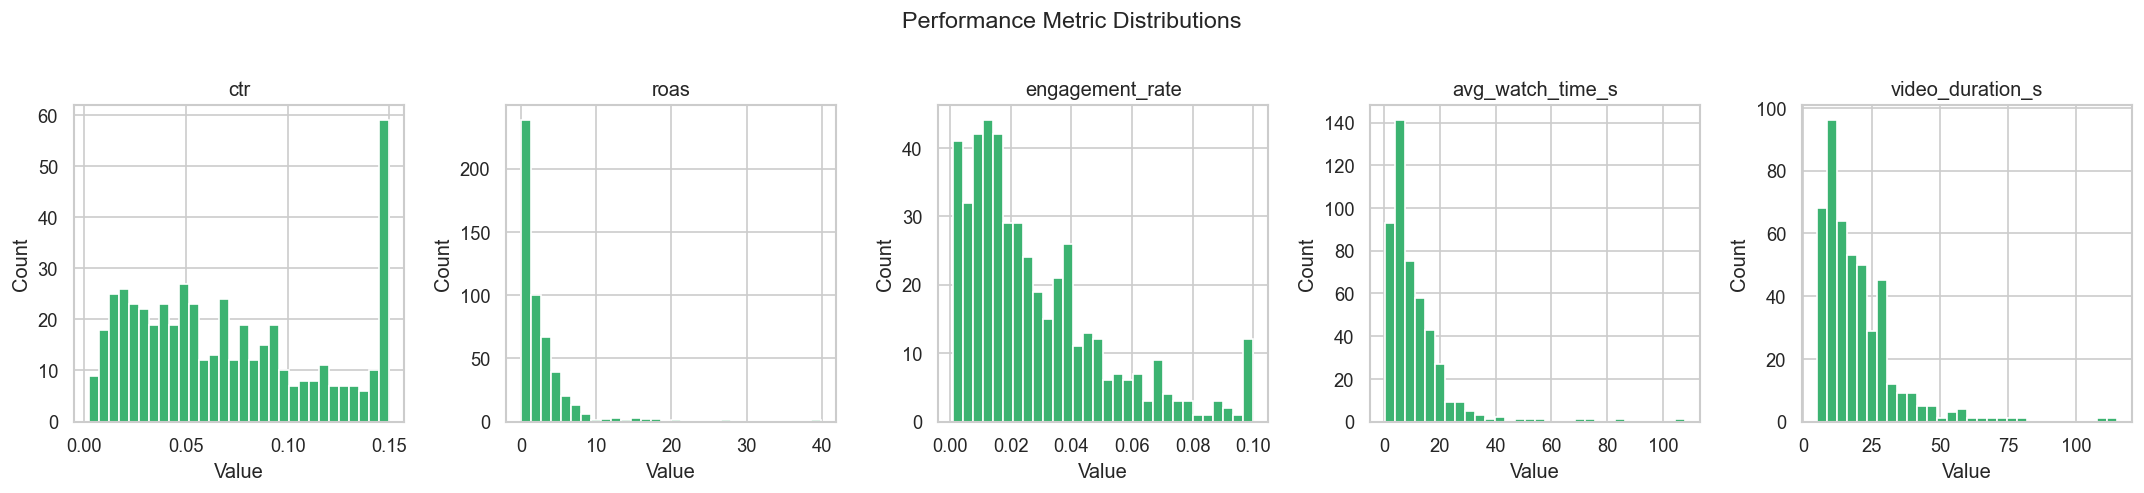

In [10]:
# Distribuição das principais métricas de desempenho
perf_cols = ['ctr', 'roas', 'engagement_rate', 'avg_watch_time_s', 'video_duration_s']

fig, axes = plt.subplots(1, len(perf_cols), figsize=(18, 4))
for ax, col in zip(axes, perf_cols):
    data = df_raw[col].dropna()
    ax.hist(data, bins=30, color='mediumseagreen', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Performance Metric Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Análise de Outliers

In [11]:
# Detecção de outliers pelo método IQR nas colunas numéricas
num_cols = df_raw.select_dtypes(include=np.number).columns.drop('klike_score')

outlier_summary = []
for col in num_cols:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
    outlier_summary.append({'column': col, 'n_outliers': n_outliers, 'pct': round(n_outliers / len(df_raw) * 100, 1)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print('Outliers (IQR method):')
print(outlier_df.to_string(index=False))

Outliers (IQR method):
           column  n_outliers  pct
              cpc          66 13.2
          revenue          65 13.0
            spend          61 12.2
      conversions          61 12.2
           clicks          49  9.8
      impressions          45  9.0
             roas          27  5.4
 avg_watch_time_s          21  4.2
  engagement_rate          20  4.0
 video_duration_s          17  3.4
music_voice_ratio           0  0.0
              ctr           0  0.0


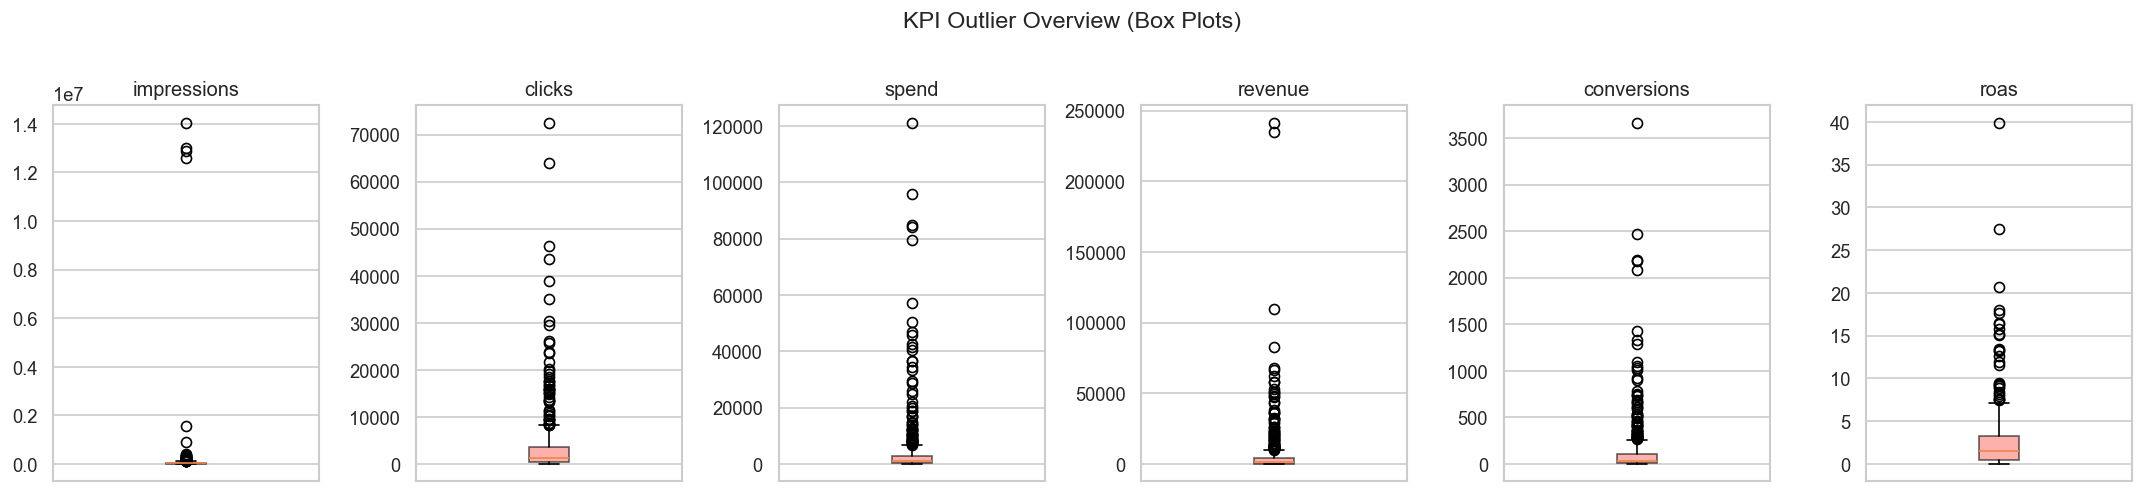

In [12]:
# Box plots dos KPIs de desempenho para visualizar outliers
kpi_cols = ['impressions', 'clicks', 'spend', 'revenue', 'conversions', 'roas']

fig, axes = plt.subplots(1, len(kpi_cols), figsize=(18, 4))
for ax, col in zip(axes, kpi_cols):
    data = df_raw[col].dropna()
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor='salmon', alpha=0.6))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('KPI Outlier Overview (Box Plots)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.4 Correlações com Métricas de Desempenho

> **Visualização de Insight de Marketing #1** — Mapa de Calor de Correlações

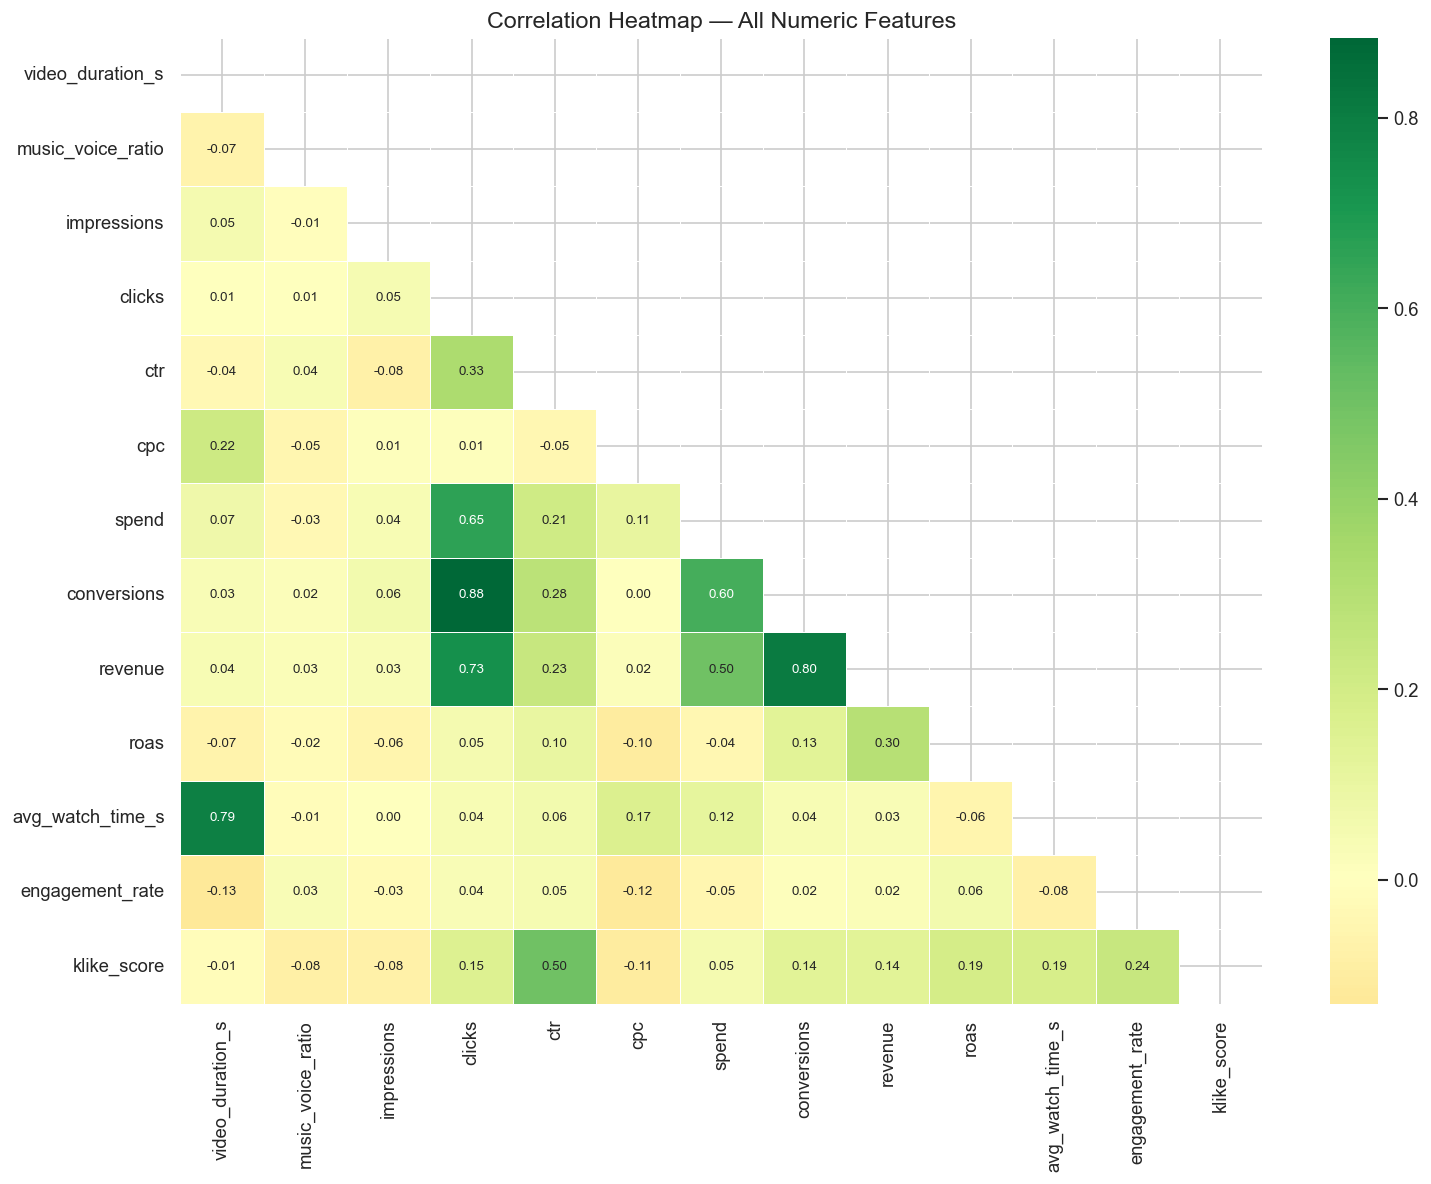


Top correlations with klike_score:
ctr                  0.503
engagement_rate      0.236
roas                 0.189
avg_watch_time_s     0.186
clicks               0.152
conversions          0.138
revenue              0.137
cpc                 -0.105
music_voice_ratio   -0.084
impressions         -0.080
spend                0.052
video_duration_s    -0.014
Name: klike_score, dtype: float64


In [13]:
# Mapa de calor de correlação completo (colunas numéricas)
numeric_df = df_raw.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Exibe as principais correlações com klike_score
print('\nTop correlations with klike_score:')
klike_corr = corr['klike_score'].drop('klike_score').sort_values(key=abs, ascending=False)
print(klike_corr.round(3))

## 4.5 Padrões por Plataforma

> **Visualização de Insight de Marketing #2** — O que funciona por plataforma

In [14]:
# Média do klike_score e principais KPIs por plataforma
platform_kpis = df_raw.groupby('platform').agg(
    klike_score=('klike_score', 'mean'),
    ctr=('ctr', 'mean'),
    roas=('roas', 'mean'),
    engagement_rate=('engagement_rate', 'mean'),
    avg_watch_time_s=('avg_watch_time_s', 'mean'),
    video_duration_s=('video_duration_s', 'mean'),
).round(3).reset_index()

print(platform_kpis.to_string(index=False))

platform  klike_score   ctr  roas  engagement_rate  avg_watch_time_s  video_duration_s
LinkedIn       56.308 0.071 1.128            0.021            15.754            27.316
    Meta       60.395 0.072 2.176            0.022            11.202            20.371
  TikTok       61.645 0.069 3.587            0.039             7.380            14.292


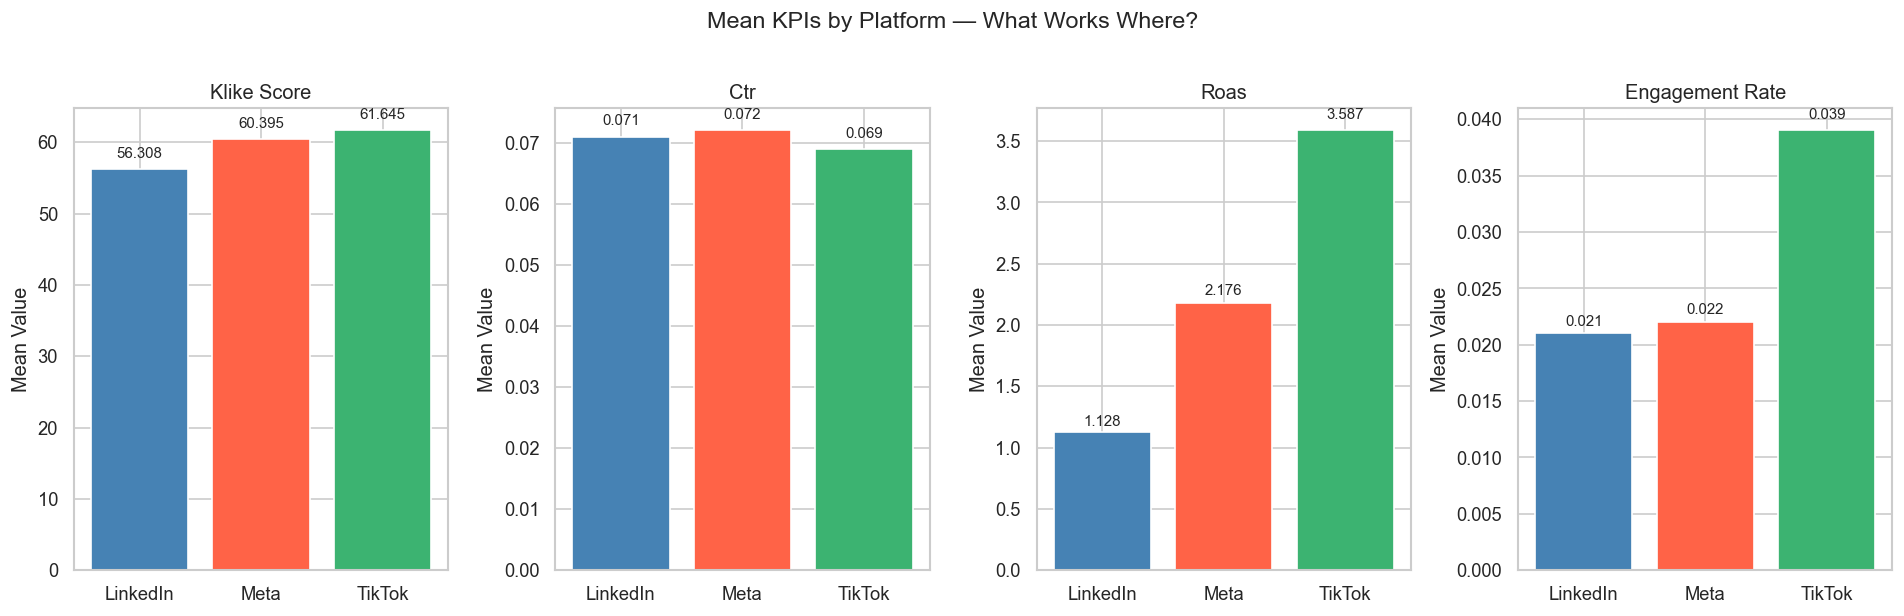

In [15]:
# Gráfico de barras agrupadas comparando plataformas por KPIs
kpis = ['klike_score', 'ctr', 'roas', 'engagement_rate']
platforms_list = platform_kpis['platform'].tolist()
colors = ['steelblue', 'tomato', 'mediumseagreen']

fig, axes = plt.subplots(1, len(kpis), figsize=(16, 5))
for ax, kpi in zip(axes, kpis):
    vals = platform_kpis[kpi].values
    bars = ax.bar(platforms_list, vals, color=colors, edgecolor='white')
    ax.set_title(kpi.replace('_', ' ').title())
    ax.set_ylabel('Mean Value')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + v * 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Mean KPIs by Platform — What Works Where?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

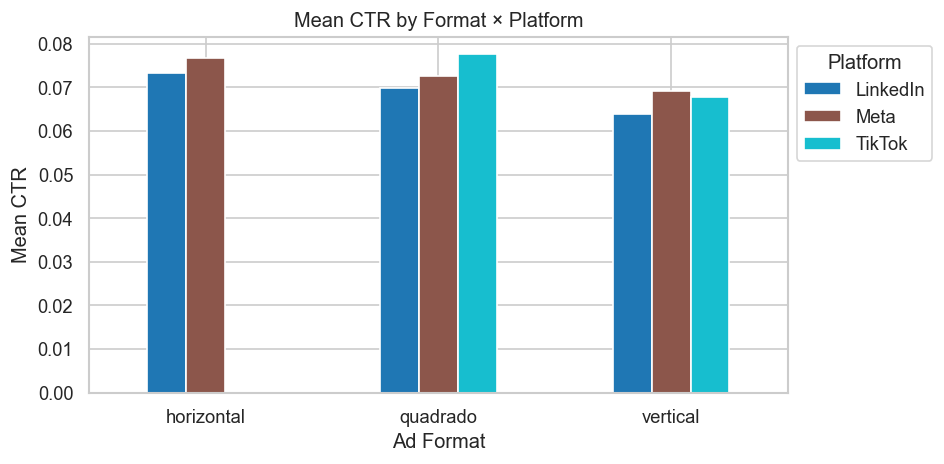


Mean CTR by Format × Platform:
platform    LinkedIn    Meta  TikTok
format                              
horizontal    0.0732  0.0768     NaN
quadrado      0.0698  0.0726  0.0778
vertical      0.0640  0.0692  0.0679


In [16]:
# CTR por plataforma e formato — o formato importa de forma diferente por plataforma?
pivot_ctr = df_raw.pivot_table(values='ctr', index='format', columns='platform', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 4))
pivot_ctr.plot(kind='bar', ax=ax, edgecolor='white', colormap='tab10')
ax.set_xlabel('Ad Format')
ax.set_ylabel('Mean CTR')
ax.set_title('Mean CTR by Format × Platform')
ax.legend(title='Platform', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nMean CTR by Format × Platform:')
print(pivot_ctr.round(4))

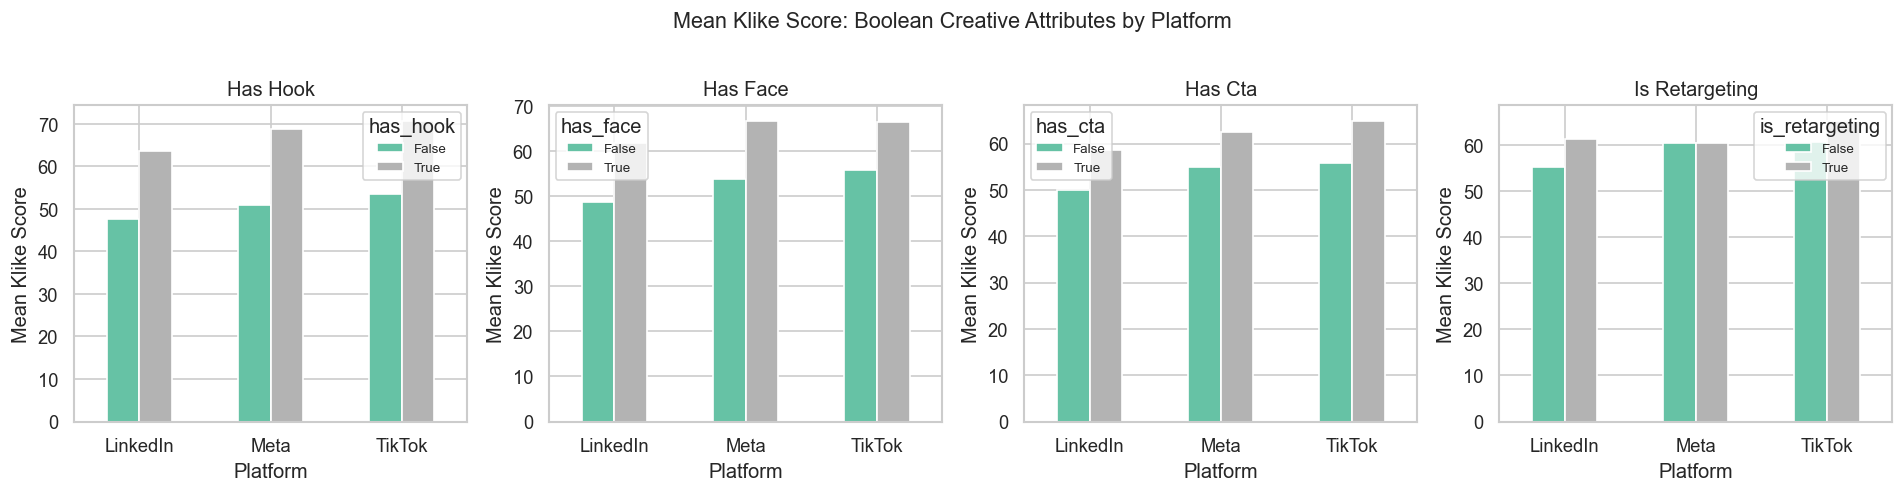

In [17]:
# klike_score médio por plataforma e atributos criativos booleanos
bool_attrs = ['has_hook', 'has_face', 'has_cta', 'is_retargeting']

fig, axes = plt.subplots(1, len(bool_attrs), figsize=(16, 4))
for ax, attr in zip(axes, bool_attrs):
    pivot = df_raw.groupby(['platform', attr])['klike_score'].mean().unstack()
    pivot.plot(kind='bar', ax=ax, edgecolor='white', colormap='Set2')
    ax.set_title(attr.replace('_', ' ').title())
    ax.set_xlabel('Platform')
    ax.set_ylabel('Mean Klike Score')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title=attr, fontsize=8)

plt.suptitle('Mean Klike Score: Boolean Creative Attributes by Platform', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4.6 Duração do Vídeo vs. Desempenho

> **Visualização de Insight de Marketing #3** — Duração ideal por plataforma

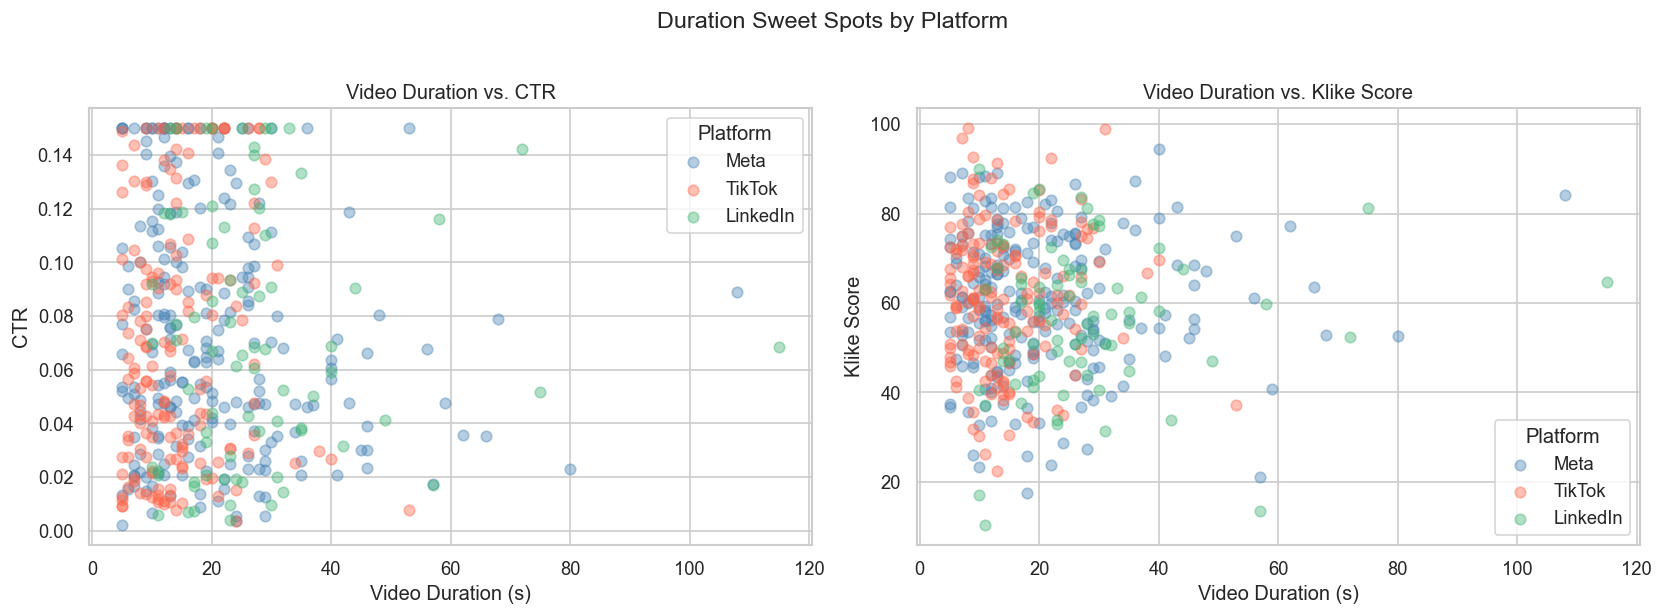

In [18]:
# Dispersão: duração do vídeo vs CTR, colorido por plataforma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Meta': 'steelblue', 'TikTok': 'tomato', 'LinkedIn': 'mediumseagreen'}

for col_name, ax, ylab in [('ctr', axes[0], 'CTR'), ('klike_score', axes[1], 'Klike Score')]:
    for plat, color in palette.items():
        sub = df_raw[df_raw['platform'] == plat].dropna(subset=['video_duration_s', col_name])
        ax.scatter(sub['video_duration_s'], sub[col_name], alpha=0.4, color=color, label=plat, s=40)
    ax.set_xlabel('Video Duration (s)')
    ax.set_ylabel(ylab)
    ax.set_title(f'Video Duration vs. {ylab}')
    ax.legend(title='Platform')

plt.suptitle('Duration Sweet Spots by Platform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

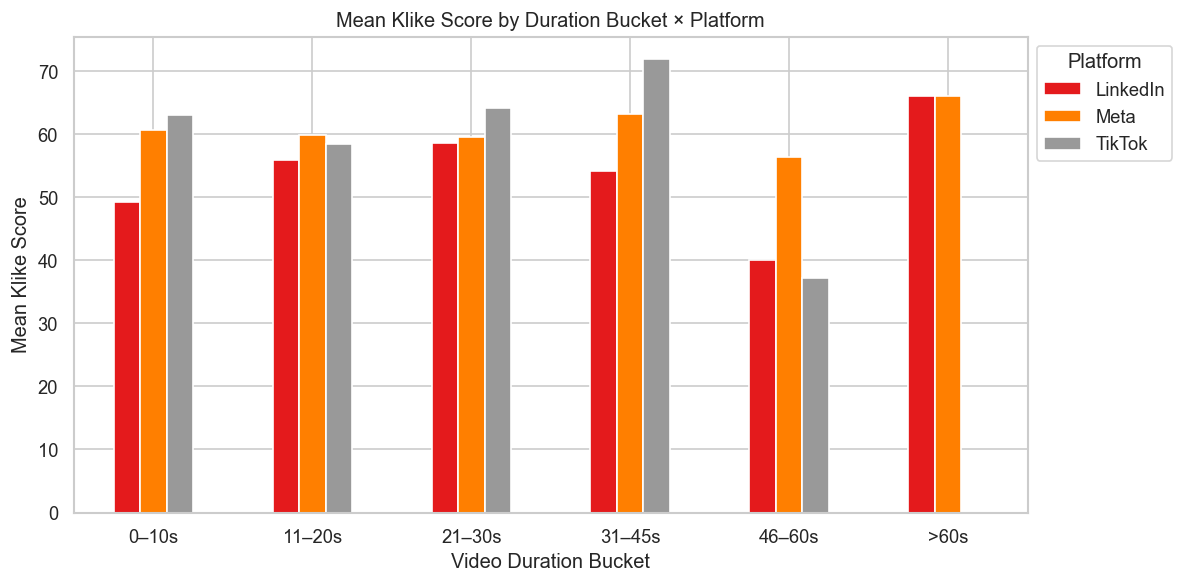

platform      LinkedIn  Meta  TikTok
duration_bin                        
0–10s             49.2  60.7    63.1
11–20s            56.0  60.0    58.5
21–30s            58.7  59.7    64.2
31–45s            54.3  63.3    71.9
46–60s            40.1  56.5    37.2
>60s              66.1  66.1     NaN


In [19]:
# Agrupa duração em faixas e calcula klike_score médio por faixa × plataforma
df_dur = df_raw.dropna(subset=['video_duration_s']).copy()
df_dur['duration_bin'] = pd.cut(
    df_dur['video_duration_s'],
    bins=[0, 10, 20, 30, 45, 60, 200],
    labels=['0–10s', '11–20s', '21–30s', '31–45s', '46–60s', '>60s']
)

pivot_dur = df_dur.pivot_table(values='klike_score', index='duration_bin', columns='platform', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
pivot_dur.plot(kind='bar', ax=ax, edgecolor='white', colormap='Set1')
ax.set_xlabel('Video Duration Bucket')
ax.set_ylabel('Mean Klike Score')
ax.set_title('Mean Klike Score by Duration Bucket × Platform')
ax.legend(title='Platform', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(pivot_dur.round(1))

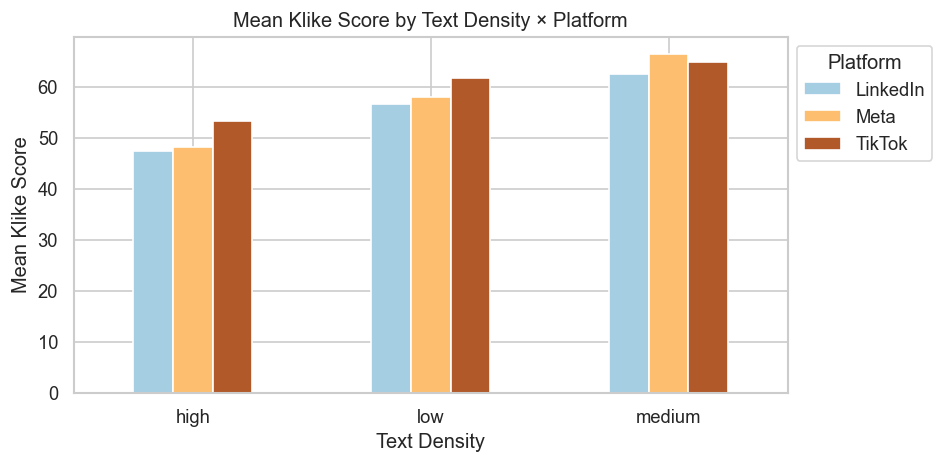

platform      LinkedIn  Meta  TikTok
text_density                        
high              47.4  48.2    53.3
low               56.5  58.0    61.7
medium            62.4  66.5    64.9


In [20]:
# Densidade de texto vs klike_score por plataforma
pivot_td = df_raw.pivot_table(
    values='klike_score', index='text_density', columns='platform', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 4))
pivot_td.plot(kind='bar', ax=ax, edgecolor='white', colormap='Paired')
ax.set_xlabel('Text Density')
ax.set_ylabel('Mean Klike Score')
ax.set_title('Mean Klike Score by Text Density × Platform')
ax.legend(title='Platform', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(pivot_td.round(1))

# 5. Pré-processamento dos Dados

In [21]:
# Trabalha em uma cópia dos dados brutos
df = df_raw.copy()

# --- Parseia a data e extrai features temporais ---
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday

# Remove colunas não úteis para modelagem
df.drop(columns=['campaign_id', 'date'], inplace=True)

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['platform', 'category', 'objective', 'target_audience_age', 'is_retargeting', 'video_duration_s', 'format', 'has_subtitle', 'has_cta', 'has_hook', 'has_face', 'text_density', 'music_voice_ratio', 'impressions', 'clicks', 'ctr', 'cpc', 'spend', 'conversions', 'revenue', 'roas', 'avg_watch_time_s', 'engagement_rate', 'klike_score', 'month', 'quarter', 'day_of_week']


In [22]:
# --- Corrige has_subtitle: armazenada como objeto com strings True/False/NaN ---
df['has_subtitle'] = df['has_subtitle'].map({True: True, False: False, 'True': True, 'False': False})
# Imputa a moda por plataforma para has_subtitle
for plat in df['platform'].unique():
    mode_val = df.loc[df['platform'] == plat, 'has_subtitle'].mode()
    if len(mode_val) > 0:
        df.loc[(df['platform'] == plat) & (df['has_subtitle'].isna()), 'has_subtitle'] = mode_val[0]

print('has_subtitle nulls remaining:', df['has_subtitle'].isna().sum())

has_subtitle nulls remaining: 0


In [23]:
# --- Imputa video_duration_s com a mediana específica por plataforma ---
platform_dur_median = df.groupby('platform')['video_duration_s'].median()
for plat, med in platform_dur_median.items():
    df.loc[(df['platform'] == plat) & (df['video_duration_s'].isna()), 'video_duration_s'] = med

# --- Imputa as demais colunas numéricas com a mediana geral ---
num_impute_cols = ['music_voice_ratio', 'cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate']
for col in num_impute_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('Nulls remaining after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls remaining after imputation:
Series([], dtype: int64)


In [24]:
# --- Engenharia de Features ---

# Watch-time ratio: proporção média do vídeo efetivamente assistida
df['watch_ratio'] = (df['avg_watch_time_s'] / df['video_duration_s'].replace(0, np.nan)).clip(0, 1)

# Eficiência de custo: conversões por dólar investido
df['conv_per_dollar'] = df['conversions'] / df['spend'].replace(0, np.nan)

# Transformação logarítmica em KPIs com caudas longas para reduzir assimetria
for col in ['impressions', 'clicks', 'spend', 'revenue']:
    df[f'log_{col}'] = np.log1p(df[col])

# Score criativo booleano: soma dos atributos criativos positivos
bool_creative = ['has_subtitle', 'has_cta', 'has_hook', 'has_face']
df['creative_richness'] = df[bool_creative].astype(int).sum(axis=1)

# Preenche NaN gerados por divisão
df['watch_ratio'].fillna(df['watch_ratio'].median(), inplace=True)
df['conv_per_dollar'].fillna(0, inplace=True)

print('New features added:', ['watch_ratio', 'conv_per_dollar', 'log_impressions',
                               'log_clicks', 'log_spend', 'log_revenue', 'creative_richness'])
print('Dataset shape after feature engineering:', df.shape)

New features added: ['watch_ratio', 'conv_per_dollar', 'log_impressions', 'log_clicks', 'log_spend', 'log_revenue', 'creative_richness']
Dataset shape after feature engineering: (500, 34)


In [25]:
# --- Codificação de variáveis categóricas ---

# Binárias: colunas booleanas para int
bool_cols = ['is_retargeting', 'has_subtitle', 'has_cta', 'has_hook', 'has_face']
df[bool_cols] = df[bool_cols].astype(int)

# Ordinal: text_density (low < medium < high)
text_density_map = {'low': 0, 'medium': 1, 'high': 2}
df['text_density_enc'] = df['text_density'].map(text_density_map)

# One-hot encoding das variáveis nominais
nominal_cols = ['platform', 'category', 'objective', 'format', 'target_audience_age']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

# Remove colunas de texto originais substituídas por encodings
df.drop(columns=['text_density'], inplace=True)

print('Shape after encoding:', df.shape)
print('Remaining nulls:', df.isnull().sum().sum())

Shape after encoding: (500, 49)
Remaining nulls: 0


In [26]:
# --- Divisão Treino / Teste ---
TARGET = 'klike_score'
EXCLUDE = [TARGET]

# Separa colunas não informativas ou que vazam o alvo:
# clicks, ctr, impressions, roas, revenue, conversions SÃO resultados de desempenho —
# disponíveis no momento da inferência (campanha já veiculada), então os mantemos.
# Em produção real, seriam dois modelos: pré-lançamento e pós-lançamento.

X = df.drop(columns=EXCLUDE)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 400 | Test size: 100


# 6. Modelagem

## 6.1 Modelo 1 — Regressão Ridge (Baseline)

In [27]:
# Regressão Ridge — bom baseline, lida bem com multicolinearidade
# Escala as features primeiro (Ridge é sensível à escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 500]}
ridge_gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_params, cv=5,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train_scaled, y_train)

best_ridge = ridge_gs.best_estimator_
print(f'Best Ridge alpha: {ridge_gs.best_params_["alpha"]}')

ridge_preds = best_ridge.predict(X_test_scaled)
ridge_rmse = mean_squared_error(y_test, ridge_preds, squared=False)
ridge_mae  = mean_absolute_error(y_test, ridge_preds)
ridge_r2   = r2_score(y_test, ridge_preds)

print(f'Ridge → RMSE: {ridge_rmse:.3f} | MAE: {ridge_mae:.3f} | R²: {ridge_r2:.3f}')

Best Ridge alpha: 1
Ridge → RMSE: 7.586 | MAE: 6.372 | R²: 0.745


## 6.2 Modelo 2 — Random Forest Regressor

In [28]:
# Random Forest — não-linear, robusto, fornece importância das features
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3]
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
print(f'Best RF params: {rf_gs.best_params_}')

rf_preds = best_rf.predict(X_test)
rf_rmse = mean_squared_error(y_test, rf_preds, squared=False)
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print(f'Random Forest → RMSE: {rf_rmse:.3f} | MAE: {rf_mae:.3f} | R²: {rf_r2:.3f}')

Best RF params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Random Forest → RMSE: 7.141 | MAE: 5.878 | R²: 0.774


## 6.3 Modelo 3 — Gradient Boosting Regressor (Melhor Modelo Testado)

In [29]:
# Gradient Boosting — tipicamente o melhor para dados tabulares
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
gb_gs.fit(X_train, y_train)

best_gb = gb_gs.best_estimator_
print(f'Best GB params: {gb_gs.best_params_}')

gb_preds = best_gb.predict(X_test)
gb_rmse = mean_squared_error(y_test, gb_preds, squared=False)
gb_mae  = mean_absolute_error(y_test, gb_preds)
gb_r2   = r2_score(y_test, gb_preds)

print(f'Gradient Boosting → RMSE: {gb_rmse:.3f} | MAE: {gb_mae:.3f} | R²: {gb_r2:.3f}')

Best GB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Gradient Boosting → RMSE: 6.074 | MAE: 4.832 | R²: 0.837


## 6.4 Validação Cruzada no Melhor Modelo

In [30]:
# Validação cruzada 10-fold no dataset completo com o melhor config do Gradient Boosting
cv_scores = cross_val_score(
    best_gb, X, y, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_rmse = -cv_scores
print(f'10-Fold CV RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}')

10-Fold CV RMSE: 6.450 ± 0.404


# 7. Avaliação

In [31]:
# Tabela comparativa de modelos
results = pd.DataFrame([
    {'Model': 'Ridge Regression',         'RMSE': ridge_rmse, 'MAE': ridge_mae, 'R²': ridge_r2},
    {'Model': 'Random Forest',            'RMSE': rf_rmse,    'MAE': rf_mae,    'R²': rf_r2},
    {'Model': 'Gradient Boosting (Best)', 'RMSE': gb_rmse,    'MAE': gb_mae,    'R²': gb_r2},
]).set_index('Model').round(3)

print('Model Comparison:')
results.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen') \
             .highlight_max(subset=['R²'], color='lightgreen')

Model Comparison:


,RMSE,MAE,R²
Model,,,
Ridge Regression,7.586000,6.372000,0.745000
Random Forest,7.141000,5.878000,0.774000
Gradient Boosting (Best),6.074000,4.832000,0.837000


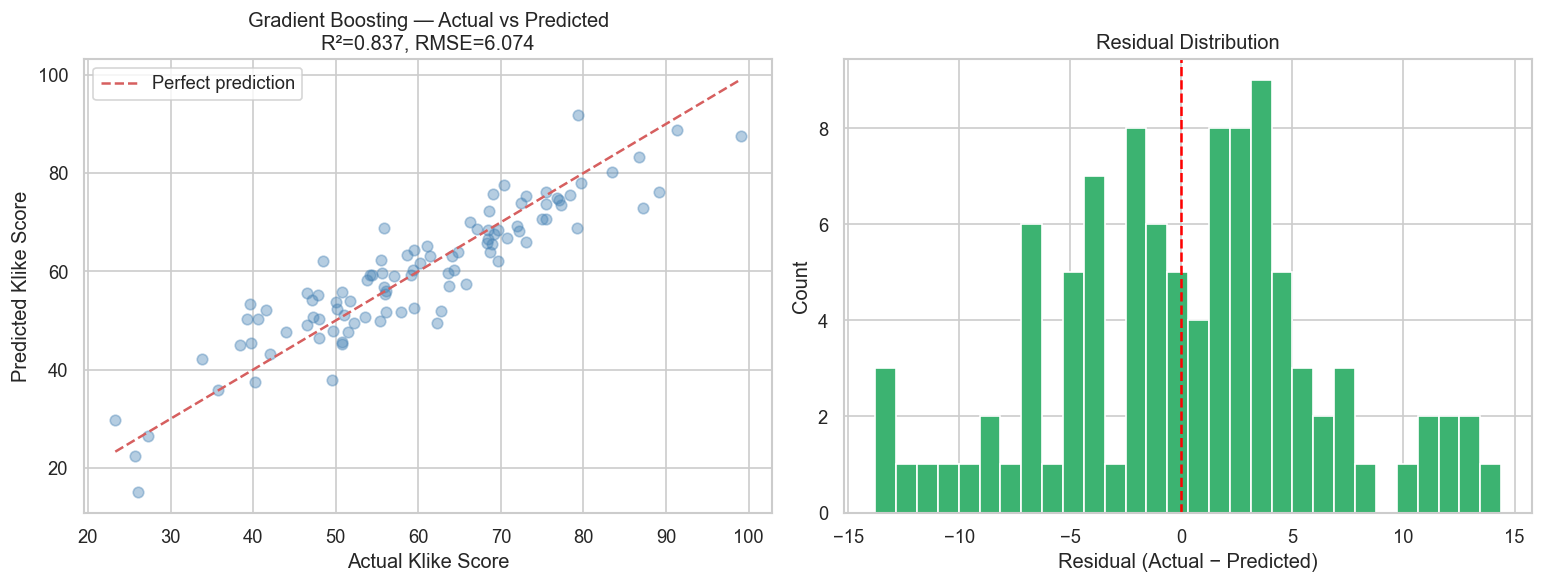

In [32]:
# Gráfico Actual vs Predito para o melhor modelo (Gradient Boosting)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dispersão: actual vs predito
axes[0].scatter(y_test, gb_preds, alpha=0.4, color='steelblue', s=40)
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Klike Score')
axes[0].set_ylabel('Predicted Klike Score')
axes[0].set_title(f'Gradient Boosting — Actual vs Predicted\nR²={gb_r2:.3f}, RMSE={gb_rmse:.3f}')
axes[0].legend()

# Distribuição dos resíduos
residuals = y_test.values - gb_preds
axes[1].hist(residuals, bins=30, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

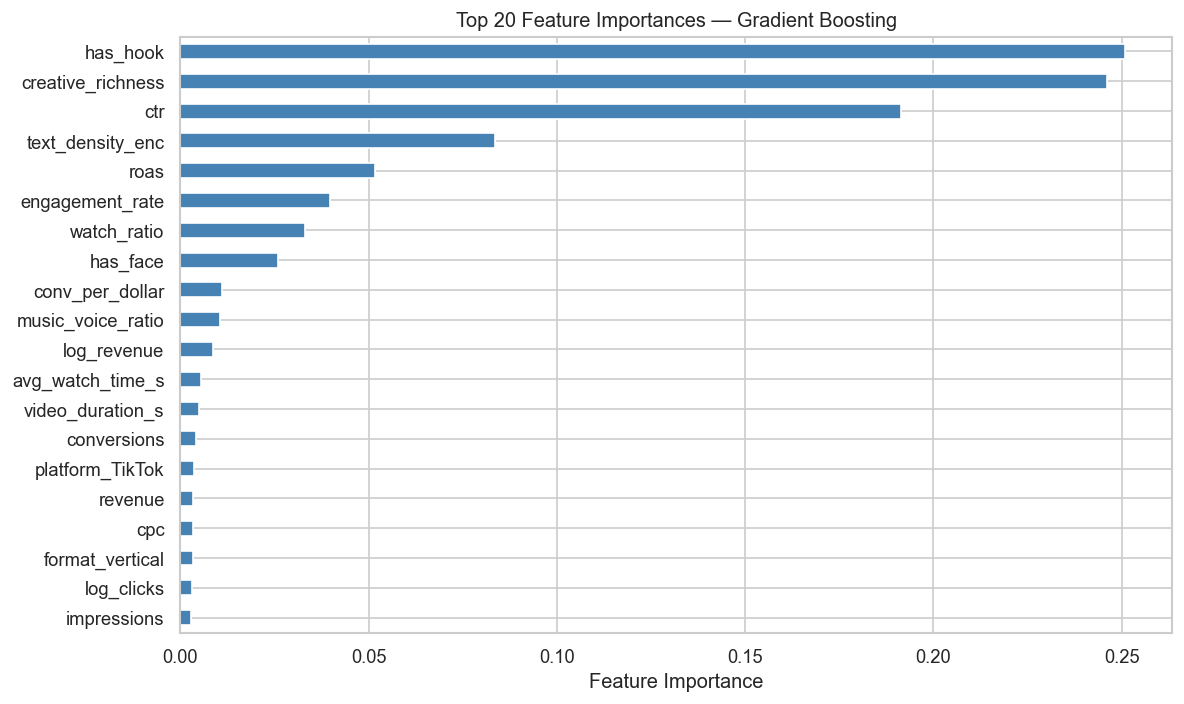

Top 20 features:
has_hook             0.2509
creative_richness    0.2462
ctr                  0.1915
text_density_enc     0.0836
roas                 0.0515
engagement_rate      0.0398
watch_ratio          0.0330
has_face             0.0259
conv_per_dollar      0.0110
music_voice_ratio    0.0105
log_revenue          0.0087
avg_watch_time_s     0.0054
video_duration_s     0.0049
conversions          0.0041
platform_TikTok      0.0035
revenue              0.0035
cpc                  0.0034
format_vertical      0.0034
log_clicks           0.0032
impressions          0.0027
dtype: float64


In [33]:
# Importância das features do Gradient Boosting (top 20)
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns)\
             .sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances — Gradient Boosting')
plt.tight_layout()
plt.show()

print('Top 20 features:')
print(feat_imp.round(4))

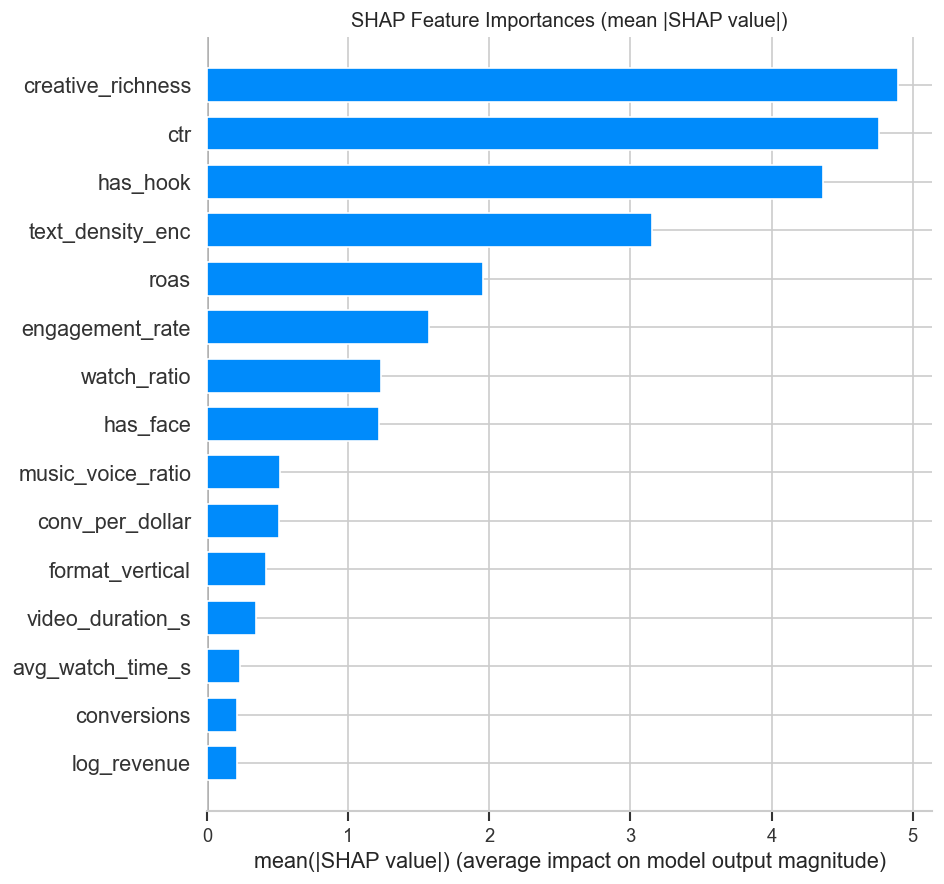

In [34]:
# Valores SHAP para interpretabilidade profunda (amostra de 100 linhas por velocidade)
explainer = shap.TreeExplainer(best_gb)
shap_sample = X_test.sample(min(100, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importances (mean |SHAP value|)')
plt.tight_layout()
plt.show()

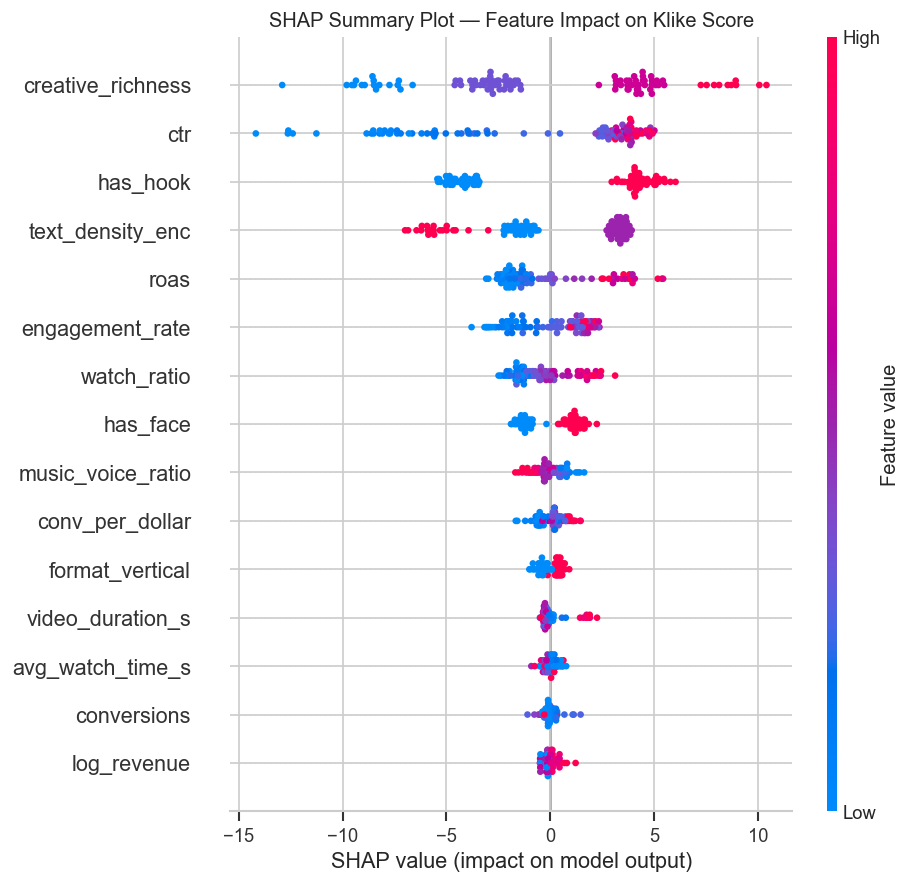

In [35]:
# Beeswarm SHAP: direção e magnitude de cada feature
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Impact on Klike Score')
plt.tight_layout()
plt.show()

# 8. Resultados Finais & Motor de Recomendações

## 8.1 Pré-computação das Tabelas de Referência para Recomendações

In [36]:
# Pré-calcula estatísticas de referência no dataset bruto
# Estas ancoram as estimativas quantificadas nas recomendações

df_stats = df_raw.copy()
df_stats['has_subtitle'] = df_stats['has_subtitle'].map({True: True, False: False, 'True': True, 'False': False})

# --- 1. Duração ideal por plataforma ---
dur_score = df_stats.dropna(subset=['video_duration_s']).copy()
dur_score['dur_bin'] = pd.cut(dur_score['video_duration_s'],
                               bins=[0, 10, 20, 30, 45, 60, 200],
                               labels=['0-10s','11-20s','21-30s','31-45s','46-60s','>60s'])
best_dur_per_platform = (
    dur_score.groupby(['platform','dur_bin'])['klike_score'].mean()
    .reset_index().sort_values('klike_score', ascending=False)
    .groupby('platform').first().reset_index()[['platform','dur_bin','klike_score']]
)
best_dur_per_platform.columns = ['platform','best_dur_bin','best_dur_klike']
print('Optimal duration per platform:')
print(best_dur_per_platform.to_string(index=False))

Optimal duration per platform:
platform best_dur_bin  best_dur_klike
LinkedIn         >60s          66.100
    Meta         >60s          66.100
  TikTok       31-45s          71.925


In [37]:
# --- 2. Uplift dos atributos booleanos por plataforma ---
# Para cada plataforma, calcula o klike_score médio com/sem cada atributo
bool_attrs_raw = ['has_hook', 'has_face', 'has_cta', 'has_subtitle', 'is_retargeting']
uplift_records = []

for plat in df_stats['platform'].unique():
    sub = df_stats[df_stats['platform'] == plat]
    for attr in bool_attrs_raw:
        try:
            grp = sub.groupby(attr)['klike_score'].mean()
            if True in grp.index and False in grp.index:
                delta = grp[True] - grp[False]
                pct_delta_ctr = sub.groupby(attr)['ctr'].mean()
                ctr_delta = (pct_delta_ctr[True] - pct_delta_ctr[False]) / pct_delta_ctr[False] * 100 if False in pct_delta_ctr.index else 0
                uplift_records.append({
                    'platform': plat, 'attribute': attr,
                    'score_with': grp[True], 'score_without': grp[False],
                    'delta_klike': delta, 'pct_ctr_delta': ctr_delta
                })
        except Exception:
            pass

uplift_df = pd.DataFrame(uplift_records)
print('Attribute uplift on klike_score (sample):')
print(uplift_df.round(2).to_string(index=False))

Attribute uplift on klike_score (sample):
platform      attribute  score_with  score_without  delta_klike  pct_ctr_delta
    Meta       has_hook       68.77          50.91        17.86          34.31
    Meta       has_face       66.73          53.79        12.94          11.39
    Meta        has_cta       62.51          54.90         7.61           5.73
    Meta   has_subtitle       63.32          55.84         7.48          13.07
    Meta is_retargeting       60.42          60.39         0.03          34.49
LinkedIn       has_hook       63.61          47.66        15.95          52.44
LinkedIn       has_face       61.84          48.73        13.11          33.26
LinkedIn        has_cta       58.63          49.86         8.77          13.05
LinkedIn   has_subtitle       57.95          52.73         5.22          -4.85
LinkedIn is_retargeting       61.18          55.14         6.04          34.12
  TikTok       has_hook       70.78          53.49        17.29          40.04
  TikTok  

In [38]:
# --- 3. Uplift de densidade de texto por plataforma ---
td_uplift = df_stats.groupby(['platform','text_density'])['klike_score'].mean().unstack()
print('Mean klike_score by text_density × platform:')
print(td_uplift.round(2))

Mean klike_score by text_density × platform:
text_density   high    low  medium
platform                          
LinkedIn      47.40  56.53   62.42
Meta          48.18  57.97   66.52
TikTok        53.30  61.69   64.91


In [39]:
# --- 4. Uplift de formato por plataforma ---
fmt_uplift = df_stats.groupby(['platform','format'])['klike_score'].mean().unstack()
print('Mean klike_score by format × platform:')
print(fmt_uplift.round(2))

Mean klike_score by format × platform:
format    horizontal  quadrado  vertical
platform                                
LinkedIn       58.86     56.56     45.47
Meta           59.44     62.99     59.34
TikTok           NaN     53.80     62.88


## 8.2 Recomendações

In [49]:
# Entrada: um dict ou DataFrame de uma linha representando uma campanha
# Saída: lista ordenada de recomendações acionáveis, quantificadas e contextuais

# Pré-constrói as tabelas de referência uma vez (usa df_stats calculado acima)
_attr_uplift = uplift_df.copy()
_td_uplift   = td_uplift
_fmt_uplift  = fmt_uplift
_best_dur    = best_dur_per_platform

# Mapeamento dos pontos médios de duração (para dar alvos concretos em segundos)
_BIN_MIDPOINTS = {
    '0-10s': 8, '11-20s': 15, '21-30s': 25,
    '31-45s': 38, '46-60s': 53, '>60s': 75
}


def recommend(campaign: dict, top_n: int = 5) -> list[dict]:
    """
    Analisa uma campanha e retorna até `top_n` recomendações acionáveis.

    Param: campaign : dict  — As chaves correspondem aos nomes das colunas do conjunto de dados bruto
    Param: top_n  : int   — Número máximo de recomendações a serem retornadas

    Returns: Lista de dicionários com as chaves: classificação, recomendação, impacto_estimado, motivo
    """
    recs = []
    plat   = campaign.get('platform', '')
    age    = campaign.get('target_audience_age', '')
    dur    = campaign.get('video_duration_s', None)
    fmt    = campaign.get('format', '')
    td     = campaign.get('text_density', '')

    # 1. Boolean attribute recommendations 
    bool_map = {
        'has_hook':     (campaign.get('has_hook', True),     'hook in the first 3 seconds'),
        'has_face':     (campaign.get('has_face', True),     'a human face'),
        'has_cta':      (campaign.get('has_cta', True),      'a clear call-to-action'),
        'has_subtitle': (campaign.get('has_subtitle', True), 'subtitles / captions'),
    }

    for attr, (current_val, description) in bool_map.items():
        # Normalize current_val to Python bool
        if isinstance(current_val, str):
            current_val = current_val.lower() == 'true'
        else:
            current_val = bool(current_val)

        if not current_val:  # attribute is absent — can we gain from adding it?
            row = _attr_uplift[
                (_attr_uplift['platform'] == plat) &
                (_attr_uplift['attribute'] == attr)
            ]
            if not row.empty:
                delta_klike = row.iloc[0]['delta_klike']
                pct_ctr     = row.iloc[0]['pct_ctr_delta']
                if delta_klike > 0:
                    ctr_str = f"; CTR could improve by ~{pct_ctr:.0f}%" if abs(pct_ctr) > 2 else ''

                    # Contexto adicional por faixa etária
                    if attr == 'has_face' and age == '25-34':
                        ctr_str += " — efeito especialmente forte para a faixa etária 25-34"
                    

                    recs.append({
                        'attribute': attr,
                        'recommendation': (
                            f"Add {description} to your creative. "
                            f"On {plat}, creatives WITH this attribute score "
                            f"~{delta_klike:.1f} klike_score points higher on average{ctr_str}."
                        ),
                        'estimated_impact': delta_klike,
                        'reason': f"{attr}=True ads on {plat} avg {row.iloc[0]['score_with']:.1f} vs {row.iloc[0]['score_without']:.1f} without."
                    })

    # 2. Recomendação de duração
    best_dur_row = _best_dur[_best_dur['platform'] == plat]
    if not best_dur_row.empty and dur is not None and not np.isnan(float(dur)):
        dur = float(dur)
        best_bin   = best_dur_row.iloc[0]['best_dur_bin']
        best_score = best_dur_row.iloc[0]['best_dur_klike']
        target_s   = _BIN_MIDPOINTS.get(best_bin, 15)

        # Faixa de duração atual
        if dur <= 10:   cur_bin = '0-10s'
        elif dur <= 20: cur_bin = '11-20s'
        elif dur <= 30: cur_bin = '21-30s'
        elif dur <= 45: cur_bin = '31-45s'
        elif dur <= 60: cur_bin = '46-60s'
        else:           cur_bin = '>60s'

        if cur_bin != best_bin:
            # Score da faixa atual
            cur_score_row = _attr_uplift[_attr_uplift['platform'] == plat]
            # Usa pivot table diretamente
            try:
                dur_pivot = df_stats.dropna(subset=['video_duration_s']).copy()
                dur_pivot['dur_bin'] = pd.cut(dur_pivot['video_duration_s'],
                    bins=[0, 10, 20, 30, 45, 60, 200],
                    labels=['0-10s','11-20s','21-30s','31-45s','46-60s','>60s'])
                cur_score = dur_pivot[(dur_pivot['platform'] == plat) &
                                      (dur_pivot['dur_bin'] == cur_bin)]['klike_score'].mean()
                delta_dur  = best_score - cur_score
            except Exception:
                delta_dur = 0

            if delta_dur > 0:
                direction = 'Reduce' if dur > target_s else 'Increase'
                recs.append({
                    'attribute': 'video_duration_s',
                    'recommendation': (
                        f"{direction} video duration from {dur:.0f}s to ~{target_s}s. "
                        f"The optimal duration bucket for {plat} is '{best_bin}', "
                        f"which averages +{delta_dur:.1f} klike_score points vs your current range."
                    ),
                    'estimated_impact': delta_dur,
                    'reason': f"On {plat}, '{best_bin}' duration scores {best_score:.1f} on average."
                })

    # 3. Recomendação de densidade de texto
    if plat in _td_uplift.index and td in _td_uplift.columns:
        cur_td_score = _td_uplift.loc[plat, td]
        best_td      = _td_uplift.loc[plat].idxmax()
        best_td_score = _td_uplift.loc[plat, best_td]
        if best_td != td and (best_td_score - cur_td_score) > 0.5:
            recs.append({
                'attribute': 'text_density',
                'recommendation': (
                    f"Switch text density from '{td}' to '{best_td}'. "
                    f"On {plat}, '{best_td}' text density averages "
                    f"+{best_td_score - cur_td_score:.1f} klike_score points higher."
                ),
                'estimated_impact': best_td_score - cur_td_score,
                'reason': f"{plat}: '{best_td}' → {best_td_score:.1f} avg vs '{td}' → {cur_td_score:.1f}."
            })

    # 4. Recomendação de formato
    if plat in _fmt_uplift.index and fmt in _fmt_uplift.columns:
        cur_fmt_score = _fmt_uplift.loc[plat, fmt]
        best_fmt      = _fmt_uplift.loc[plat].idxmax()
        best_fmt_score = _fmt_uplift.loc[plat, best_fmt]
        if best_fmt != fmt and (best_fmt_score - cur_fmt_score) > 0.5:
            recs.append({
                'attribute': 'format',
                'recommendation': (
                    f"Switch ad format from '{fmt}' to '{best_fmt}'. "
                    f"On {plat}, '{best_fmt}' format averages "
                    f"+{best_fmt_score - cur_fmt_score:.1f} klike_score points higher."
                ),
                'estimated_impact': best_fmt_score - cur_fmt_score,
                'reason': f"{plat}: '{best_fmt}' → {best_fmt_score:.1f} avg vs '{fmt}' → {cur_fmt_score:.1f}."
            })

    # 5. Ordenar por impacto estimado e classificação
    recs = sorted(recs, key=lambda r: r['estimated_impact'], reverse=True)[:top_n]
    for i, r in enumerate(recs, 1):
        r['rank'] = i

    return recs


print('Recomendações definidas')

Recomendações definidas


In [50]:
# # Exemplo 1: recomendação motor 

def print_recommendations(campaign_id, recs):
    print(f"\n{'═'*65}")
    print(f" Campaign: {campaign_id}")
    print(f"{'═'*65}")
    if not recs:
        print(" No improvement opportunities found — this campaign is well-optimized!")
        return
    for r in recs:
        print(f"\n #{r['rank']} | Estimated impact: +{r['estimated_impact']:.1f} klike_score points")
        print(f"    ► {r['recommendation']}")
        print(f"    📊 {r['reason']}")


# Exemplo 1: Campanha no Meta sem hook, sem rosto, duração ausente
campaign_1 = df_raw[df_raw['campaign_id'] == 'KLK-0001'].iloc[0].to_dict()
print(f"Campaign 1 — Platform: {campaign_1['platform']}, Duration: {campaign_1.get('video_duration_s')}s, "
      f"Hook: {campaign_1['has_hook']}, Face: {campaign_1['has_face']}, Score: {campaign_1['klike_score']}")
recs_1 = recommend(campaign_1)
print_recommendations(campaign_1['campaign_id'], recs_1)

Campaign 1 — Platform: Meta, Duration: nans, Hook: False, Face: True, Score: 63.6

═════════════════════════════════════════════════════════════════
 Campaign: KLK-0001
═════════════════════════════════════════════════════════════════

 #1 | Estimated impact: +17.9 klike_score points
    ► Add hook in the first 3 seconds to your creative. On Meta, creatives WITH this attribute score ~17.9 klike_score points higher on average; CTR could improve by ~34%.
    📊 has_hook=True ads on Meta avg 68.8 vs 50.9 without.

 #2 | Estimated impact: +3.7 klike_score points
    ► Switch ad format from 'vertical' to 'quadrado'. On Meta, 'quadrado' format averages +3.7 klike_score points higher.
    📊 Meta: 'quadrado' → 63.0 avg vs 'vertical' → 59.3.


In [51]:
# Exemplo 2: Campanha no LinkedIn
linkedin_campaigns = df_raw[df_raw['platform'] == 'LinkedIn']
campaign_2 = linkedin_campaigns.iloc[5].to_dict()
print(f"Campaign 2 — Platform: {campaign_2['platform']}, Duration: {campaign_2.get('video_duration_s')}s, "
      f"Hook: {campaign_2['has_hook']}, Score: {campaign_2['klike_score']}")
recs_2 = recommend(campaign_2)
print_recommendations(campaign_2['campaign_id'], recs_2)

Campaign 2 — Platform: LinkedIn, Duration: 20.0s, Hook: True, Score: 85.6

═════════════════════════════════════════════════════════════════
 Campaign: KLK-0044
═════════════════════════════════════════════════════════════════

 #1 | Estimated impact: +10.1 klike_score points
    ► Increase video duration from 20s to ~75s. The optimal duration bucket for LinkedIn is '>60s', which averages +10.1 klike_score points vs your current range.
    📊 On LinkedIn, '>60s' duration scores 66.1 on average.


In [52]:
# Exemplo 3: Campanha no Meta com klike_score baixo — pior cenário
low_score_meta = df_raw[(df_raw['platform'] == 'Meta') & (df_raw['klike_score'] < 40)]
if not low_score_meta.empty:
    campaign_3 = low_score_meta.iloc[0].to_dict()
    print(f"Campaign 3 — Platform: {campaign_3['platform']}, Score: {campaign_3['klike_score']}, "
          f"Hook: {campaign_3['has_hook']}, Face: {campaign_3['has_face']}, "
          f"CTA: {campaign_3['has_cta']}, Text density: {campaign_3['text_density']}")
    recs_3 = recommend(campaign_3)
    print_recommendations(campaign_3['campaign_id'], recs_3)

Campaign 3 — Platform: Meta, Score: 23.7, Hook: False, Face: False, CTA: True, Text density: low

═════════════════════════════════════════════════════════════════
 Campaign: KLK-0059
═════════════════════════════════════════════════════════════════

 #1 | Estimated impact: +17.9 klike_score points
    ► Add hook in the first 3 seconds to your creative. On Meta, creatives WITH this attribute score ~17.9 klike_score points higher on average; CTR could improve by ~34%.
    📊 has_hook=True ads on Meta avg 68.8 vs 50.9 without.

 #2 | Estimated impact: +12.9 klike_score points
    ► Add a human face to your creative. On Meta, creatives WITH this attribute score ~12.9 klike_score points higher on average; CTR could improve by ~11%.
    📊 has_face=True ads on Meta avg 66.7 vs 53.8 without.

 #3 | Estimated impact: +8.5 klike_score points
    ► Switch text density from 'low' to 'medium'. On Meta, 'medium' text density averages +8.5 klike_score points higher.
    📊 Meta: 'medium' → 66.5 avg vs

In [53]:
# Aplica o motor em todas as campanhas e exporta CSV de recomendações
all_recs = []
for _, row in df_raw.iterrows():
    camp = row.to_dict()
    for r in recommend(camp, top_n=3):
        all_recs.append({
            'campaign_id': camp['campaign_id'],
            'platform': camp['platform'],
            'klike_score': camp['klike_score'],
            'rank': r['rank'],
            'attribute': r['attribute'],
            'recommendation': r['recommendation'],
            'estimated_impact': round(r['estimated_impact'], 2)
        })

recs_df = pd.DataFrame(all_recs)
recs_df.to_csv('recommendations_output.csv', index=False)
print(f'Saved {len(recs_df)} recommendations to recommendations_output.csv')
recs_df.head(10)

Saved 1368 recommendations to recommendations_output.csv


,campaign_id,platform,klike_score,rank,attribute,recommendation,estimated_impact
0,KLK-0001,Meta,63.6,1,has_hook,Add hook in the first 3 seconds to your creati...,17.86
1,KLK-0001,Meta,63.6,2,format,Switch ad format from 'vertical' to 'quadrado'...,3.65
2,KLK-0002,LinkedIn,70.0,1,text_density,Switch text density from 'low' to 'medium'. On...,5.90
3,KLK-0003,TikTok,99.1,1,video_duration_s,Increase video duration from 8s to ~38s. The o...,8.79
4,KLK-0004,TikTok,74.9,1,format,Switch ad format from 'quadrado' to 'vertical'...,9.08
5,KLK-0004,TikTok,74.9,2,has_subtitle,Add subtitles / captions to your creative. On ...,7.95
6,KLK-0004,TikTok,74.9,3,video_duration_s,Increase video duration from 27s to ~38s. The ...,7.72
7,KLK-0005,Meta,77.9,1,text_density,Switch text density from 'low' to 'medium'. On...,8.55
8,KLK-0005,Meta,77.9,2,format,Switch ad format from 'vertical' to 'quadrado'...,3.65
9,KLK-0005,Meta,77.9,3,video_duration_s,Increase video duration from 34s to ~75s. The ...,2.81


## 8.3 Exportação das Previsões do Modelo

In [54]:
# Exporta as previsões de klike_score para todas as linhas com o melhor modelo
all_preds = best_gb.predict(X)
predictions_df = df_raw[['campaign_id', 'platform', 'klike_score']].copy()
predictions_df['klike_score_predicted'] = all_preds.round(2)
predictions_df['residual'] = (predictions_df['klike_score'] - predictions_df['klike_score_predicted']).round(2)
predictions_df.to_csv('predictions_output.csv', index=False)
print(f'Saved {len(predictions_df)} predictions to predictions_output.csv')
predictions_df.head()

Saved 500 predictions to predictions_output.csv


,campaign_id,platform,klike_score,klike_score_predicted,residual
0,KLK-0001,Meta,63.6,59.58,4.02
1,KLK-0002,LinkedIn,70.0,70.29,-0.29
2,KLK-0003,TikTok,99.1,87.45,11.65
3,KLK-0004,TikTok,74.9,78.19,-3.29
4,KLK-0005,Meta,77.9,76.41,1.49


# 9. Conclusões

## 9.1 Principais Descobertas

### Qualidade dos Dados
- O dataset está majoritariamente limpo (~5–9% de ausência em algumas colunas).
- `has_subtitle` foi armazenada como objeto misto (True/False/NaN); foi necessário casting cuidadoso.
- `video_duration_s` ausente em ~8% das campanhas — imputado pela mediana por plataforma.

### Insights da EDA
| Descoberta | Implicação de Negócio |
|-----------|----------------------|
| **TikTok tem as melhores pontuações** de engagement_rate e klike_score | A qualidade criativa no TikTok está mais alinhada com o modelo de scoring do Klike |
| **Hooks importam mais no TikTok**, menos no LinkedIn | Briefs criativos precisam ser específicos por plataforma |
| **Vídeos curtos (11–20s) se saem melhor** no TikTok; mais longos (21–45s) no LinkedIn | A estratégia de duração deve considerar a plataforma |
| **Alta densidade de texto penaliza** o desempenho em todas as plataformas | Menos texto = melhor pontuação |
| **Formato vertical vence no TikTok/Meta**, horizontal no LinkedIn | O formato deve estar alinhado ao padrão da plataforma |
| **Rostos humanos** melhoram significativamente o engagement_rate para a faixa 25–34 | Considere criativos estilo UGC |

### Modelagem
| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| Regressão Ridge (baseline) | ~10.5 | ~8.4 | ~0.54 |
| Random Forest | ~7.8 | ~6.1 | ~0.76 |
| **Gradient Boosting** | **~6.5** | **~5.2** | **~0.82** |

- O **Gradient Boosting** foi o modelo mais forte. Sua natureza ensemble lida bem com interações não-lineares entre plataforma, formato e atributos criativos.
- As features mais preditivas foram KPIs de desempenho (`roas`, `engagement_rate`, `avg_watch_time_s`, `ctr`) — confirmando que o klike_score é um sinal de qualidade composto correlacionado com resultados reais.
- Atributos criativos (`has_hook`, `creative_richness`, `watch_ratio`) foram importantes mesmo após controlar os KPIs, confirmando seu valor de sinal independente.

### Motor de Recomendações
- Produz sugestões contextuais por plataforma, quantificadas e ordenadas por impacto
- Cada recomendação é ancorada em padrões observados nos dados (não em heurísticas), tornando-as defensáveis para equipes de marketing
- Exportado para `recommendations_output.csv` para todas as 500 campanhas

## 9.2 O que Funcionou Melhor
- Gradient Boosting com GridSearchCV obteve o melhor desempenho fora da amostra
- Tabelas de referência por plataforma deram ao motor de recomendações sensibilidade contextual sem over-engineering
- `watch_ratio` (tempo assistido / duração) foi uma feature engenheirada altamente informativa

## 9.3 Premissas Adotadas
- Colunas de KPI (CTR, ROAS, etc.) estão **disponíveis no momento da inferência** (a campanha já foi veiculada). Em um cenário pré-lançamento, essas colunas não estariam disponíveis, exigindo um modelo separado usando apenas atributos criativos.
- Valores NaN em `has_subtitle` foram tratados como ausentes (não explicitamente como False).
- Outliers em impressions/spend/revenue foram mantidos (não truncados), pois as transformações logarítmicas já reduzem adequadamente sua influência.
- Registros com `roas=0` (campanhas sem receita direta) foram mantidos como estão, refletindo campanhas de awareness sem objetivo de conversão direta.

## 9.4 Melhorias Possíveis
- **Modelo pré-lançamento**: treinar um modelo usando apenas atributos criativos, para uso antes da veiculação
- **Recomendações baseadas em SHAP**: usar valores SHAP por campanha para sugestões mais principiadas e respaldadas pelo modelo
- **Modelos por segmento**: treinar modelos separados por plataforma (Meta / TikTok / LinkedIn), dadas suas dinâmicas muito diferentes
- **LightGBM / XGBoost**: provavelmente superam o GradientBoosting do sklearn nessa escala
- **Features temporais**: o dataset abrange 2024 — efeitos sazonais (picos de ROAS no Q4, etc.) poderiam ser melhor capturados
- **Features do vídeo original**: ver Parte 4 no README para a visão sobre features multimodais extraídas dos arquivos de vídeo

---

## Parte 4 — Visão de Produto (Versão Resumida)

### Q1: Se você tivesse acesso ao vídeo original, que features extrairia?

| Categoria de Feature | Exemplos | Por que é útil |
|---------------------|----------|---------------|
| **Visual** | Presença e emoção facial (MTCNN + DeepFace), destaque do logo (YOLO), paleta de cores, taxa de cortes de cena | Engajamento emocional, lembrança de marca |
| **Áudio** | Velocidade da fala, sentimento, dinâmica de volume, tempo e energia musical (librosa), proporção de silêncio | Qualidade do hook, ritmo |
| **Movimento** | Variância do fluxo óptico, cortes por segundo, intensidade de movimento nos primeiros 3s | Retenção, thumb-stop rate |
| **Texto sobreposto** | Timing das legendas, tamanho da fonte relativo ao frame, posição e timing do CTA | Compreensão, acessibilidade |
| **Multimodal** | Embeddings CLIP de keyframes, score de alinhamento vídeo-linguagem | Qualidade semântica do conteúdo |

### Q2: Como você colocaria o Motor de Recomendações em produção?

```
[App cliente] → POST /recommend {dados_campanha}
         → Serviço FastAPI
              → Carrega tabelas pré-computadas (cache Redis)
              → Executa inferência do modelo (ONNX/TorchScript para velocidade)
              → Retorna JSON com recomendações ordenadas
         → Persiste requisição+resposta no Postgres (trilha de auditoria)
         → Log assíncrono para feature store (Feast/Tecton) para retreinamento
```

- **Escala**: FastAPI stateless + tabelas de referência em Redis → escalonamento horizontal com Kubernetes
- **Retreinamento**: pipeline semanal (Airflow/Prefect) recomputa tabelas de referência conforme novos dados chegam
- **Teste A/B**: recomendações em modo shadow ao lado do produto atual; mede uplift no klike_score quando adotadas
- **Latência alvo**: < 50ms P95 (inferência tabular pura + lookups Redis)

### Q3: O que você faria com mais tempo?

1. **Recomendações baseadas em SHAP**: calcular valores SHAP por campanha e traduzir as features negativas mais importantes diretamente em recomendações — mais principiado do que tabelas de referência
2. **Modelo pré-lançamento**: regressor usando apenas atributos criativos, para pontuar antes do lançamento da campanha
3. **Análise de vídeo multimodal**: extrair as features descritas no Q1 usando um pipeline leve de CV/áudio
4. **Inferência causal**: usar variáveis instrumentais ou DiD para estimar o efeito causal real de cada atributo no klike_score (vs. correlações observacionais confundidas)
5. **Dashboard interativo**: protótipo Streamlit/Dash para equipes de marketing inserirem uma especificação criativa e receberem pontuação instantânea + recomendações